# AI-Driven Detection and Prevention of Cross-Site Scripting (XSS) Attacks
## Complete Implementation Based on Research Paper

## Install Libraries

In [ ]:

# !pip install tensorflow
# !pip install shap
# !pip install seaborn
# !pip install wordcloud
# !pip install scikit-learn

## Import Libraries

In [2]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve


In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Embedding, GRU
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import cross_val_score

In [4]:
import shap
import joblib

import warnings
warnings.filterwarnings('ignore')

/Users/vn58zms/Documents/iitj/AI-Driven-XSS-Detection/xss_ai_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
import pandas as pd
df1 = pd.read_csv('XSS_dataset_new.csv')
print(f"XSS_dataset_new.csv shape: {df1.shape}")
df1.head()


XSS_dataset_new.csv shape: (6042, 3)


,Unnamed: 0,Sentence,Label
0,1,<script>alert(1)</script>,1
1,2,"<input type=""file"" id=""fileInput"" /><script>co...",1
2,3,<style>:target {color:red;}</style><* id=x sty...,1
3,4,<video controls onsuspend=alert(1)><source src...,1
4,5,<audio controls onsuspend=alert(1)><source src...,1


In [8]:
df1.Label.value_counts()

Label
0    4408
1    1634
Name: count, dtype: int64

## Load Dataset

In [6]:

df2 = pd.read_csv("XSS_dataset.csv")
print(f"XSS_dataset.csv shape: {df2.shape}")

# Ensure both DataFrames have the same columns
# Standardize column names if needed
print(f"\ndf1 columns: {df1.columns.tolist()}")
print(f"df2 columns: {df2.columns.tolist()}")

# Combine both datasets
df = pd.concat([df1, df2], ignore_index=True)
df.dropna(subset=['Sentence', 'Label'], inplace=True)

print(f"\nCombined dataset shape: {df.shape}")
print(f"\nLabel distribution:\n{df['Label'].value_counts()}")
print(f"\nNull values:\n{df.isnull().sum()}")


XSS_dataset.csv shape: (13686, 3)

df1 columns: ['Unnamed: 0', 'Sentence', 'Label']
df2 columns: ['Unnamed: 0', 'Sentence', 'Label']

Combined dataset shape: (19728, 3)

Label distribution:
Label
0    10721
1     9007
Name: count, dtype: int64

Null values:
Unnamed: 0    0
Sentence      0
Label         0
dtype: int64


In [11]:
df.Label.value_counts()

Label
1    7373
0    6313
Name: count, dtype: int64

## Exploratory Data Analysis

/var/folders/b6/yxx_9yps7334ck_11rr4r95c0000gp/T/ipykernel_38452/2560690723.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
/var/folders/b6/yxx_9yps7334ck_11rr4r95c0000gp/T/ipykernel_38452/2560690723.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Safe (0)', 'XSS Attack (1)'], fontsize=12, fontweight='bold')


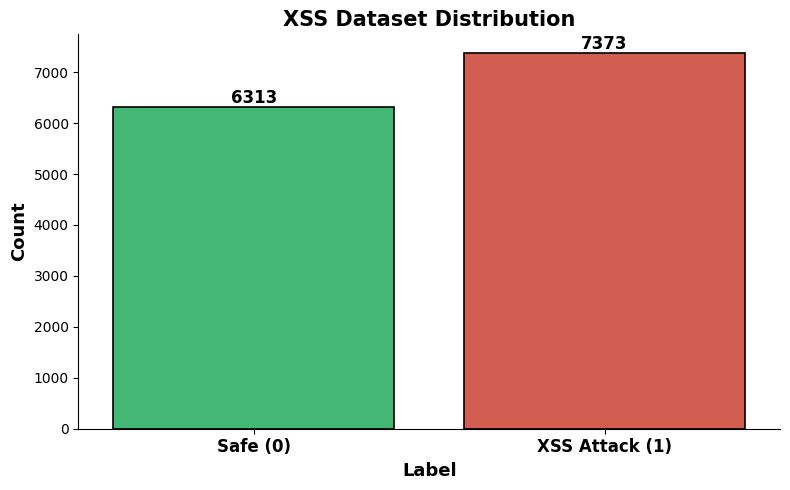

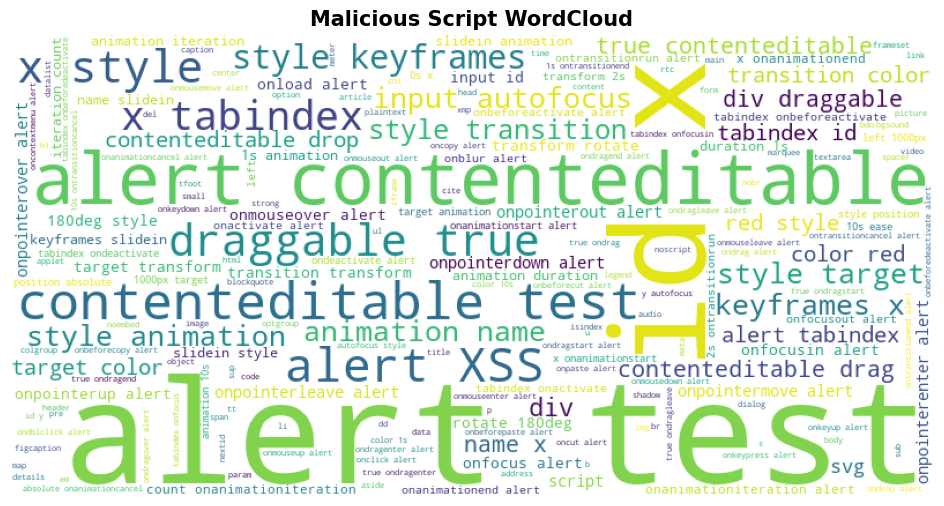

In [4]:

plt.figure(figsize=(8, 5))
ax = sns.countplot(
    x=df['Label'],
    palette=['#2ecc71', '#e74c3c'],
    edgecolor='black',
    linewidth=1.2
)
ax.set_xticklabels(['Safe (0)', 'XSS Attack (1)'], fontsize=12, fontweight='bold')
ax.set_xlabel('Label', fontsize=13, fontweight='bold')
ax.set_ylabel('Count', fontsize=13, fontweight='bold')
ax.set_title('XSS Dataset Distribution', fontsize=15, fontweight='bold')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

malicious_text = " ".join(df[df['Label']==1]['Sentence'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(malicious_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis('off')
plt.title("Malicious Script WordCloud", fontsize=15, fontweight='bold')
plt.show()


## Label Encoding

In [7]:

encoder = LabelEncoder()

df['Label'] = encoder.fit_transform(df['Label'])


## Train Test Split

In [8]:

X = df['Sentence']
y = df['Label']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


## TF-IDF Feature Extraction

In [9]:

tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train).toarray()
X_test_tfidf = tfidf.transform(X_test).toarray()

print(X_train_tfidf.shape)


(15782, 5000)


## LSTM Temporal Feature Extraction

In [10]:

tokenizer = Tokenizer(num_words=5000)

tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

max_length = 100

X_train_pad = pad_sequences(X_train_seq, maxlen=max_length)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_length)


## Build LSTM Model

In [11]:

lstm_model = Sequential()

lstm_model.add(
    Embedding(
        input_dim=5000,
        output_dim=128,
        input_length=max_length
    )
)

lstm_model.add(LSTM(64))

lstm_model.add(Dense(1, activation='sigmoid'))

lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Train LSTM Model

In [1]:

history = lstm_model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)


NameError: name 'lstm_model' is not defined

## Extract LSTM Features

In [13]:

feature_extractor = Sequential(lstm_model.layers[:-1])

lstm_train_features = feature_extractor.predict(X_train_pad)
lstm_test_features = feature_extractor.predict(X_test_pad)

print(lstm_train_features.shape)


343/343 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
(10948, 64)


## Feature Fusion (LSTF)

In [14]:

X_train_fusion = np.concatenate(
    [X_train_tfidf, lstm_train_features],
    axis=1
)

X_test_fusion = np.concatenate(
    [X_test_tfidf, lstm_test_features],
    axis=1
)

print(X_train_fusion.shape)


(10948, 5064)


## Random Forest Model

In [15]:

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=400,
    random_state=42
)

rf_model.fit(X_train_fusion, y_train)

rf_pred = rf_model.predict(X_test_fusion)

print("RF Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))


RF Accuracy: 0.9974433893352812
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1260
           1       1.00      1.00      1.00      1478

    accuracy                           1.00      2738
   macro avg       1.00      1.00      1.00      2738
weighted avg       1.00      1.00      1.00      2738



## Logistic Regression

In [16]:

lr_model = LogisticRegression()

lr_model.fit(X_train_fusion, y_train)

lr_pred = lr_model.predict(X_test_fusion)

print("LR Accuracy:", accuracy_score(y_test, lr_pred))


LR Accuracy: 0.9974433893352812


## Gaussian Naive Bayes

In [17]:

gnb_model = GaussianNB()

gnb_model.fit(X_train_fusion, y_train)

gnb_pred = gnb_model.predict(X_test_fusion)

print("GNB Accuracy:", accuracy_score(y_test, gnb_pred))


GNB Accuracy: 0.8849525200876552


## Decision Tree

In [18]:

dt_model = DecisionTreeClassifier(max_depth=10)

dt_model.fit(X_train_fusion, y_train)

dt_pred = dt_model.predict(X_test_fusion)

print("DT Accuracy:", accuracy_score(y_test, dt_pred))


DT Accuracy: 0.9974433893352812


## GRU Model

In [19]:

gru_model = Sequential()

gru_model.add(
    Embedding(
        input_dim=5000,
        output_dim=128,
        input_length=max_length
    )
)

gru_model.add(GRU(64))

gru_model.add(Dense(1, activation='sigmoid'))

gru_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

gru_model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=32
)


Epoch 1/5
343/343 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - accuracy: 0.9892 - loss: 0.0557
Epoch 2/5
343/343 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.9986 - loss: 0.0056
Epoch 3/5
343/343 ━━━━━━━━━━━━━━━━━━━━ 12s 36ms/step - accuracy: 0.9994 - loss: 0.0031
Epoch 4/5
343/343 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.9995 - loss: 0.0025
Epoch 5/5
343/343 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.9995 - loss: 0.0023


## Confusion Matrix

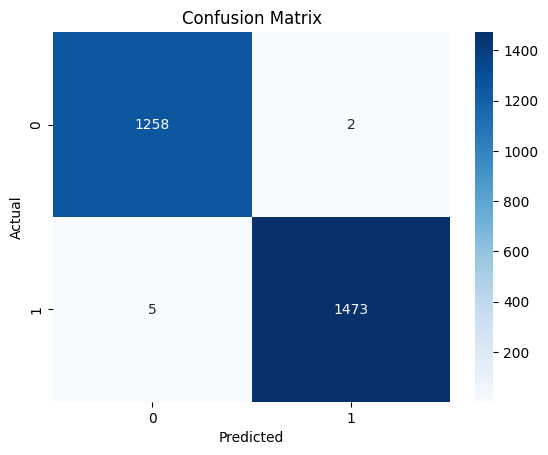

In [20]:

cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


## ROC Curve

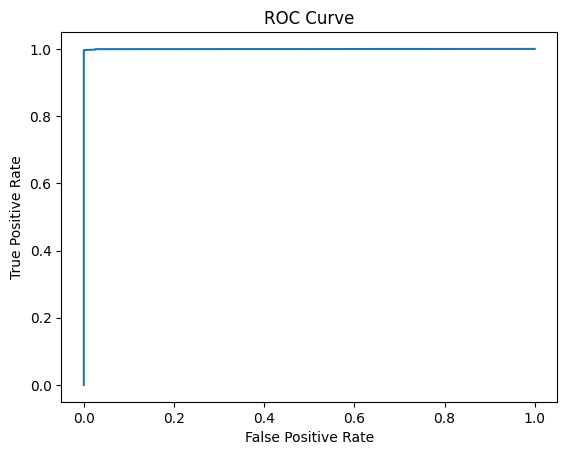

ROC AUC: 0.9995948514723887


In [21]:

rf_probs = rf_model.predict_proba(X_test_fusion)[:,1]

fpr, tpr, threshold = roc_curve(y_test, rf_probs)

plt.plot(fpr, tpr)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.show()

print("ROC AUC:", roc_auc_score(y_test, rf_probs))


## K-Fold Cross Validation

In [22]:

scores = cross_val_score(
    rf_model,
    X_train_fusion,
    y_train,
    cv=10
)

print("K-Fold Accuracy:", scores.mean())
print("Standard Deviation:", scores.std())


K-Fold Accuracy: 0.9993603966842803
Standard Deviation: 0.0008225857115871894


## SHAP Explainable AI

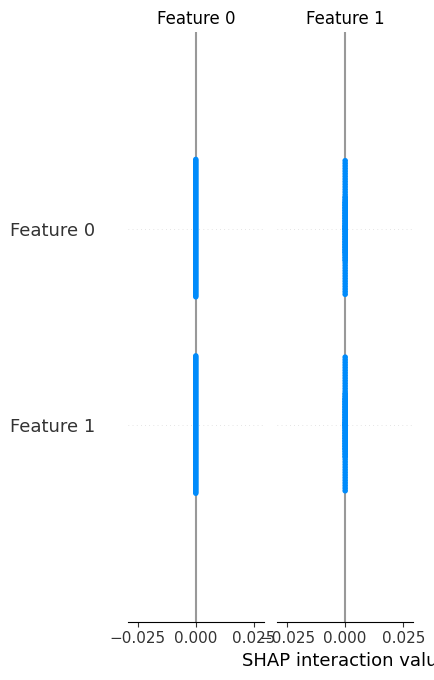

In [23]:

explainer = shap.TreeExplainer(rf_model)

shap_values = explainer.shap_values(X_test_fusion[:100])

shap.summary_plot(
    shap_values,
    X_test_fusion[:100]
)


## Save Model

In [24]:

joblib.dump(rf_model, "xss_rf_model.pkl")

print("Model Saved Successfully")


Model Saved Successfully


In [25]:
joblib.dump(tfidf, "xss_tfidf_vectorizer.pkl")
joblib.dump(tokenizer, "xss_tokenizer.pkl")

print("TF-IDF Vectorizer and Tokenizer Saved Successfully")

TF-IDF Vectorizer and Tokenizer Saved Successfully


In [26]:
lstm_model.save("xss_lstm_model.h5")
print("LSTM Model Saved Successfully")

LSTM Model Saved Successfully
